In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4", "H2O"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4", "H2O"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4", "H2O"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4", "H2O"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for H2O
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for H2O


In [4]:
dff["CO2_CoCiP"] = dff["CO2"] + dff["CoCiP"]
dfo["CO2_CoCiP"] = dfo["CO2"] + dfo["CoCiP"]

dff["NOx_H2O"] = dff["NOx"] + dff["H2O"]
dfo["NOx_H2O"] = dfo["NOx"] + dfo["H2O"]

dff["Total"] = dff["CO2"] + dff["CoCiP"] + dff["NOx"] + dff["H2O"]
dfo["Total"] = dfo["CO2"] + dfo["CoCiP"] + dfo["NOx"] + dfo["H2O"]

In [5]:
# contrails: 17 instead of 57.4 (-70%)
f_contrail = 17 / 57.4
# NOx: 29 instead of 17.5 (+66%)
f_nox = 29 / 17.5
# H2O: 3.2 instead of 2 (+60%)
f_h2o = 3.2 / 2

print(f_contrail, f_nox, f_h2o)  # factors

0.2961672473867596 1.6571428571428573 1.6


In [6]:
dff2 = dff.copy()
dfo2 = dfo.copy()

In [7]:
dff2 = dff2.assign(CoCiP=dff2.CoCiP * f_contrail)
dff2 = dff2.assign(NOx=dff2.NOx * f_nox)
dff2 = dff2.assign(H2O=dff2.H2O * f_h2o)

In [8]:
dfo2 = dfo2.assign(CoCiP=dfo2.CoCiP * f_contrail)
dfo2 = dfo2.assign(NOx=dfo2.NOx * f_nox)
dfo2 = dfo2.assign(H2O=dfo2.H2O * f_h2o)

In [9]:
dff2["CO2_CoCiP"] = dff2["CO2"] + dff2["CoCiP"]
dfo2["CO2_CoCiP"] = dfo2["CO2"] + dfo2["CoCiP"]

dff2["NOx_H2O"] = dff2["NOx"] + dff2["H2O"]
dfo2["NOx_H2O"] = dfo2["NOx"] + dfo2["H2O"]

dff2["Total"] = dff2["CO2"] + dff2["CoCiP"] + dff2["NOx"] + dff2["H2O"]
dfo2["Total"] = dfo2["CO2"] + dfo2["CoCiP"] + dfo2["NOx"] + dfo2["H2O"]

In [10]:
from cane.utils import df_diff

# create aggregates (total)
org_sum = (
    dff[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby("flight_id").sum().reset_index()
)
opt_sum = (
    dfo[["flight_id", "fuel_burn", "nox", "co2", "CO2", "NOx", "H2O", "CoCiP", "CO2_CoCiP", "NOx_H2O",
         "Total"]]
    .groupby("flight_id").sum().reset_index()
)
my_diff = df_diff(org_sum, opt_sum, on=["flight_id"], keep_originals=True)
my_diff = pd.merge(
    my_diff,
    dff.groupby("flight_id").day.first(),
    on="flight_id",
)

In [11]:
cols = ["CO2", "CoCiP", "NOx", "H2O", "CO2_CoCiP", "NOx_H2O", "Total"]

my_diff2 = df_diff(
    dff2[cols + ["flight_id"]].groupby("flight_id").sum().reset_index(),
    dfo2[cols + ["flight_id"]].groupby("flight_id").sum().reset_index(),
    keep_originals=True
)
my_diff2 = pd.merge(
    my_diff2,
    dff2.groupby("flight_id").day.first(),
    on="flight_id",
)

In [12]:
n = 4112

a1_left = len(my_diff.query("CO2_CoCiP_diff < 0").flight_id.unique())
b1_left = len(my_diff.query("Total_diff < 0").flight_id.unique())
a1_right = n - a1_left
b1_right = n - b1_left

a2_left = len(my_diff2.query("CO2_CoCiP_diff < 0").flight_id.unique())
b2_left = len(my_diff2.query("Total_diff < 0").flight_id.unique())
a2_right = n - a2_left
b2_right = n - b2_left

In [13]:
a1_left, b1_left, a1_right, b1_right

(3503, 3455, 609, 657)

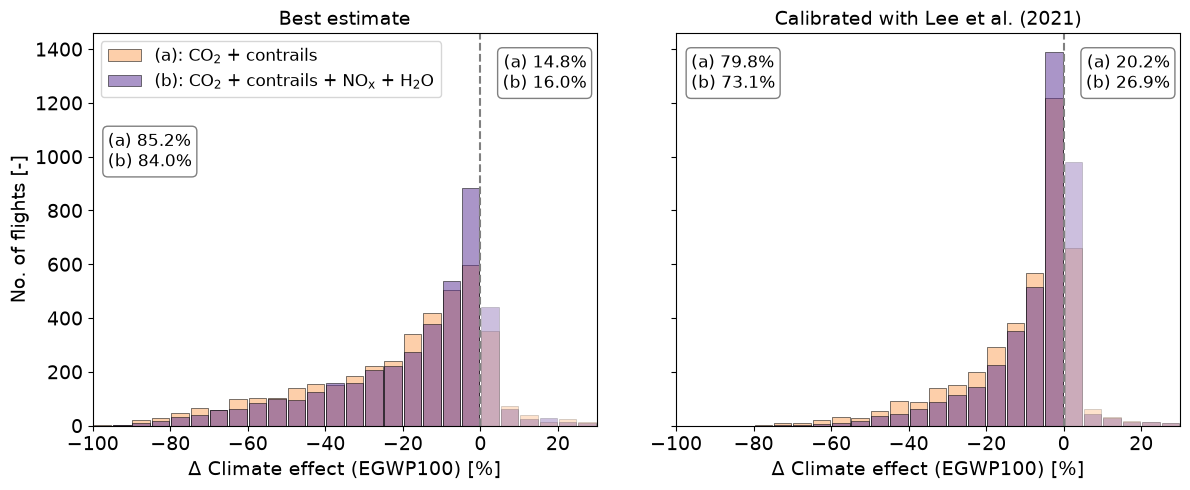

In [14]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5), sharey=True)
plt.subplots_adjust(wspace=1)

for ax, df in zip(axes, [my_diff, my_diff2]):
    ax1 = sns.histplot(df["CO2_CoCiP_reldiff"] * 100, label="(a): CO$_2$ + contrails",
                       binwidth=5, binrange=(-150, 100),
                       alpha=.5, color=sns.color_palette("Oranges")[2], shrink=0.9,
                       ax=ax)  #, edgecolor="white", linewidth=0.5)
    ax2 = sns.histplot(df["Total_reldiff"] * 100,
                       label=r"(b): CO$_2$ + contrails + NO$\rm_x$ + H$_2$O",
                       binwidth=5, binrange=(-150, 100),
                       alpha=.5, color=sns.color_palette("Purples")[5], shrink=0.9,
                       ax=ax)  #edgecolor="white", linewidth=0.5)

    for patch in ax1.patches:
        if patch.get_x() >= 0:
            patch.set_alpha(0.3)  # lighter alpha
            # patch.set_hatch("//")  # or hatches, or both

for ax in axes:
    ax.set_xlim([-100, 30])
    ax.set_xlabel("$\Delta$ Climate effect (EGWP100) [%]", fontsize=14)
    ax.tick_params(labelsize=14)
    ax.axvline(0, color="gray", linestyle="--")

# axes[1].set_xlim([-100, 20])
axes[0].set_ylabel("No. of flights [-]", fontsize=14)

axes[0].set_title("Best estimate", fontsize=14)
axes[1].set_title("Calibrated with Lee et al. (2021)", fontsize=14)

# plt.title("Climate optimized flights only")
# plt.grid(axis=None)
axes[0].legend(fontsize=12, loc="upper left")

# Left figure
fig.text(
    0.03, 0.75, f"(a) {(a1_left / n * 100):.1f}%\n(b) {(b1_left / n * 100):.1f}%",
    ha="left", va="top",
    transform=axes[0].transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)
fig.text(
    0.98, 0.95, f"(a) {(a1_right / n * 100):.1f}%\n(b) {(b1_right / n * 100):.1f}%",
    ha="right", va="top",
    transform=axes[0].transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)

fig.text(
    0.03, 0.95, f"(a) {(a2_left / n * 100):.1f}%\n(b) {(b2_left / n * 100):.1f}%",
    ha="left", va="top",
    transform=axes[1].transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)
fig.text(
    0.98, 0.95, f"(a) {(a2_right / n * 100):.1f}%\n(b) {(b2_right / n * 100):.1f}%",
    ha="right", va="top",
    transform=axes[1].transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey")
)

fig.tight_layout()
plt.savefig("../figures/figE1.png", dpi=300, bbox_inches="tight")

In [15]:
# Sect 4
fids = my_diff.query("CO2_CoCiP_diff < 0 and Total_diff > 0").flight_id.unique()
print(len(fids), len(fids) / 4112 * 100)

# Sect 4
fids = my_diff2.query("CO2_CoCiP_diff < 0 and Total_diff > 0").flight_id.unique()
print(len(fids), len(fids) / 4112 * 100)

88 2.140077821011673
389 9.460116731517509


In [16]:
# for discussion
contrail = 26932
nox = 733
h2o = 64

print(contrail * 0.3) # -70%
print(nox * 1.66) # + 66%
print(h2o * 1.6) # + 60%

8079.599999999999
1216.78
102.4
